# Star-to-Galaxy Ratio vs. r-band Magnitude

Plot `log10(N_stars / N_galaxies)` vs. r-band CModel magnitude for both ECDFS and COSMOS fields, using the V8 mixture-model fitting approach.

Star and galaxy counts per 0.5-mag bin are derived from the mixture weights:
- `N_stars = wU * N` where `wU = 1 - sum(wR_k)` is the unresolved (star) fraction
- `N_galaxies = (1 - wU) * N`

In [38]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = Path.cwd().resolve()
for candidate in [path, *path.parents]:
    if (candidate / 'src').exists() and (candidate / 'paper_convergence').exists():
        repo_root = candidate
        break
else:
    raise RuntimeError('Could not locate repo root containing src/ and paper_convergence/')

for d in [repo_root / 'src', repo_root / 'paper_convergence' / 'code']:
    if str(d) not in sys.path:
        sys.path.insert(0, str(d))

import pipeline as pipl
import psf_cmodel_fit as pcf
from paper_plot_style import set_paper_style, save_figure

set_paper_style()
print(f'Repo root: {repo_root}')

Repo root: C:\Users\Nemal\Desktop\star-galaxy-separation


In [39]:
fields = ['DP2_ECDFS_objects', 'DP2_COSMOS_objects']
field_labels = ['ECDFS', 'COSMOS']

data_dir = repo_root / 'data' / 'private'
data = [pipl.load_csv_dp2(str(data_dir / f'{f}.fits')) for f in fields]
data_mag = [pipl.magnitude_calculations(d, d['ebv'] * 3.10 / 1.20) for d in data]

for label, df in zip(field_labels, data_mag):
    print(f'{label}: {len(df):,} objects')

c:\Users\Nemal\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Nemal\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Nemal\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Nemal\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Nemal\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Nemal\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountere

ECDFS: 732,402 objects
COSMOS: 865,287 objects


In [40]:
from star_galaxy_ratio import pad_2to3_skewnorm_freemu, fallback_failed_bins, extract_star_fraction

bin_edges = np.arange(16.0, 26.5, 0.5)
cmodel_bins = [(bin_edges[i], bin_edges[i + 1]) for i in range(len(bin_edges) - 1)]

BRIGHT_FAINT_THRESHOLD = 22.0
bright_bins = [(lo, hi) for lo, hi in cmodel_bins if 0.5 * (lo + hi) < BRIGHT_FAINT_THRESHOLD]
faint_bins = [(lo, hi) for lo, hi in cmodel_bins if 0.5 * (lo + hi) >= BRIGHT_FAINT_THRESHOLD]

print(f'{len(cmodel_bins)} bins from {bin_edges[0]} to {bin_edges[-1]}')
print(f'Bright (n_resolved=2): {len(bright_bins)}, Faint (n_resolved=3): {len(faint_bins)}')

20 bins from 16.0 to 26.0
Bright (n_resolved=2): 12, Faint (n_resolved=3): 8


In [41]:
band = 'r'
fit_results = {}

for field_idx, label in enumerate(field_labels):
    print(f'\n=== {label} ===')
    fits_bright = pcf.fit_slices(
        data_mag[field_idx], band, n_resolved=2,
        cmodel_bins=bright_bins, model_type='skewnorm', free_star_mean=True,
    )
    fits_faint = pcf.fit_slices(
        data_mag[field_idx], band, n_resolved=3,
        cmodel_bins=faint_bins, model_type='skewnorm', free_star_mean=True,
    )
    combined = [pad_2to3_skewnorm_freemu(r) for r in fits_bright] + list(fits_faint)
    combined = fallback_failed_bins(combined)
    fit_results[label] = combined

    n_ok = sum(1 for r in combined if r['success'] and not r.get('fallback', False))
    n_fb = sum(1 for r in combined if r.get('fallback', False))
    print(f'  {n_ok} successful fits, {n_fb} fallbacks, {len(combined)} total bins')


=== ECDFS ===
  20 successful fits, 0 fallbacks, 20 total bins

=== COSMOS ===
  20 successful fits, 0 fallbacks, 20 total bins


In [42]:
ratio_data = {}

for label in field_labels:
    rows = []
    for r in fit_results[label]:
        wU = extract_star_fraction(r)
        N = r['n']
        center = r['cmodel_center']

        if np.isnan(wU) or N == 0:
            rows.append({'mag_center': center, 'N_total': N, 'wU': np.nan,
                         'N_stars': np.nan, 'N_galaxies': np.nan,
                         'log_ratio': np.nan, 'valid': False})
            continue

        N_stars = wU * N
        N_galaxies = (1.0 - wU) * N

        if N_stars <= 0 or N_galaxies <= 0:
            log_ratio = np.nan
            valid = False
        else:
            log_ratio = np.log10(N_galaxies / N_stars)
            valid = True

        rows.append({'mag_center': center, 'N_total': N, 'wU': wU,
                     'N_stars': N_stars, 'N_galaxies': N_galaxies,
                     'log_ratio': log_ratio, 'valid': valid})

    ratio_data[label] = pd.DataFrame(rows)

for label in field_labels:
    print(f'\n{label}:')
    print(ratio_data[label].to_string(index=False))


ECDFS:
 mag_center  N_total       wU      N_stars    N_galaxies  log_ratio  valid
      16.25       67 0.615623    41.246724     25.753276  -0.204557   True
      16.75      230 0.692573   159.291799     70.708201  -0.352724   True
      17.25      319 0.608870   194.229684    124.770316  -0.192204   True
      17.75      329 0.577946   190.144394    138.855606  -0.136520   True
      18.25      532 0.557516   296.598391    235.401609  -0.100359   True
      18.75      729 0.548819   400.088712    328.911288  -0.085078   True
      19.25     1055 0.456233   481.325460    573.674540   0.076227   True
      19.75     1551 0.366852   568.987401    982.012599   0.237014   True
      20.25     2232 0.303460   677.323810   1554.676190   0.360844   True
      20.75     3242 0.222282   720.638145   2521.361855   0.543918   True
      21.25     4938 0.176886   873.461283   4064.538717   0.667768   True
      21.75     7246 0.126310   915.245430   6330.754570   0.839918   True
      22.25    10

In [43]:
from astropy.coordinates import SkyCoord
from astropy import units as u

cosmos2020 = pd.read_csv(repo_root / 'data' / 'cosmos2020_farmer_truth_catalog_github.csv')
cosmos2020 = cosmos2020.dropna(subset=['ra', 'dec', 'label'])
cosmos2020 = cosmos2020[cosmos2020['label'].isin(['star', 'galaxy'])].copy()
print(f'COSMOS2020 sources with star/galaxy labels: {len(cosmos2020)}')

ext_coords = SkyCoord(ra=cosmos2020['ra'].values * u.deg,
                      dec=cosmos2020['dec'].values * u.deg, frame='icrs')
dp2_coords = SkyCoord(ra=data_mag[1]['coord_ra'].values * u.deg,
                      dec=data_mag[1]['coord_dec'].values * u.deg, frame='icrs')

idx, sep2d, _ = ext_coords.match_to_catalog_sky(dp2_coords)
good_match = sep2d < 1.0 * u.arcsec
print(f'Matched within 1 arcsec: {good_match.sum()}')

matched_ext = cosmos2020.iloc[good_match.nonzero()[0]].copy()
matched_ext['dp2_idx'] = idx[good_match]
matched_ext['match_sep_arcsec'] = sep2d[good_match].arcsec
matched_ext = matched_ext.sort_values('match_sep_arcsec').drop_duplicates(subset='dp2_idx', keep='first')

r_mag_col = 'r_modelFlux_mag'
matched_ext['r_mag'] = data_mag[1].iloc[matched_ext['dp2_idx'].values][r_mag_col].values

cosmos_ext_rows = []
for lo, hi in cmodel_bins:
    center = 0.5 * (lo + hi)
    in_bin = matched_ext[(matched_ext['r_mag'] >= lo) & (matched_ext['r_mag'] < hi)]
    n_stars = (in_bin['label'] == 'star').sum()
    n_galaxies = (in_bin['label'] == 'galaxy').sum()

    if n_stars > 0 and n_galaxies > 0:
        log_ratio = np.log10(n_galaxies / n_stars)
        valid = True
    else:
        log_ratio = np.nan
        valid = False

    cosmos_ext_rows.append({'mag_center': center, 'N_total': len(in_bin),
                            'N_stars': n_stars, 'N_galaxies': n_galaxies,
                            'log_ratio': log_ratio, 'valid': valid})

cosmos_ext_ratio = pd.DataFrame(cosmos_ext_rows)
print(f'\nCOSMOS external label counts (matched): {len(matched_ext)} '
      f'({(matched_ext["label"] == "star").sum()} stars, '
      f'{(matched_ext["label"] == "galaxy").sum()} galaxies)')
print(cosmos_ext_ratio.to_string(index=False))

COSMOS2020 sources with star/galaxy labels: 580691
Matched within 1 arcsec: 422104

COSMOS external label counts (matched): 417776 (16245 stars, 401531 galaxies)
 mag_center  N_total  N_stars  N_galaxies  log_ratio  valid
      16.25        6        0           6        NaN  False
      16.75        9        0           9        NaN  False
      17.25       36        0          36        NaN  False
      17.75       69        7          62   0.947294   True
      18.25      254      141         113  -0.096141   True
      18.75      442      244         198  -0.090725   True
      19.25      691      328         363   0.044033   True
      19.75      971      385         586   0.182437   True
      20.25     1366      422         944   0.349660   True
      20.75     2114      554        1560   0.449615   True
      21.25     3073      721        2352   0.513502   True
      21.75     4358      836        3522   0.624583   True
      22.25     6408      827        5581   0.829207   Tru

In [44]:
ext_ratio_data = {}

for field_idx, label in enumerate(field_labels):
    df = data_mag[field_idx]
    r_ext = pd.to_numeric(df['r_extendedness'], errors='coerce')
    r_mag = df['r_modelFlux_mag']

    rows = []
    for lo, hi in cmodel_bins:
        center = 0.5 * (lo + hi)
        in_bin = (r_mag >= lo) & (r_mag < hi) & np.isfinite(r_ext)
        n_stars = (r_ext[in_bin] == 0.0).sum()
        n_galaxies = (r_ext[in_bin] == 1.0).sum()

        if n_stars > 0 and n_galaxies > 0:
            log_ratio = np.log10(n_galaxies / n_stars)
            valid = True
        else:
            log_ratio = np.nan
            valid = False

        rows.append({'mag_center': center, 'N_total': int(in_bin.sum()),
                     'N_stars': int(n_stars), 'N_galaxies': int(n_galaxies),
                     'log_ratio': log_ratio, 'valid': valid})

    ext_ratio_data[label] = pd.DataFrame(rows)
    n_used = ext_ratio_data[label]['N_total'].sum()
    print(f'{label}: {n_used:,} objects with unflagged r_extendedness')

for label in field_labels:
    print(f'\n{label} (extendedness):')
    print(ext_ratio_data[label].to_string(index=False))

ECDFS: 365,934 objects with unflagged r_extendedness
COSMOS: 455,091 objects with unflagged r_extendedness

ECDFS (extendedness):
 mag_center  N_total  N_stars  N_galaxies  log_ratio  valid
      16.25       84       41          43   0.020685   True
      16.75      251      205          46  -0.648996   True
      17.25      354      272          82  -0.520755   True
      17.75      375      259         116  -0.348842   True
      18.25      581      351         230  -0.183579   True
      18.75      790      418         372  -0.050633   True
      19.25     1108      500         608   0.084934   True
      19.75     1570      599         971   0.209792   True
      20.25     2238      721        1517   0.323050   True
      20.75     3165      744        2421   0.512422   True
      21.25     4831      901        3930   0.639668   True
      21.75     7044      922        6122   0.822162   True
      22.25    10454      951        9503   0.999680   True
      22.75    16219      974 

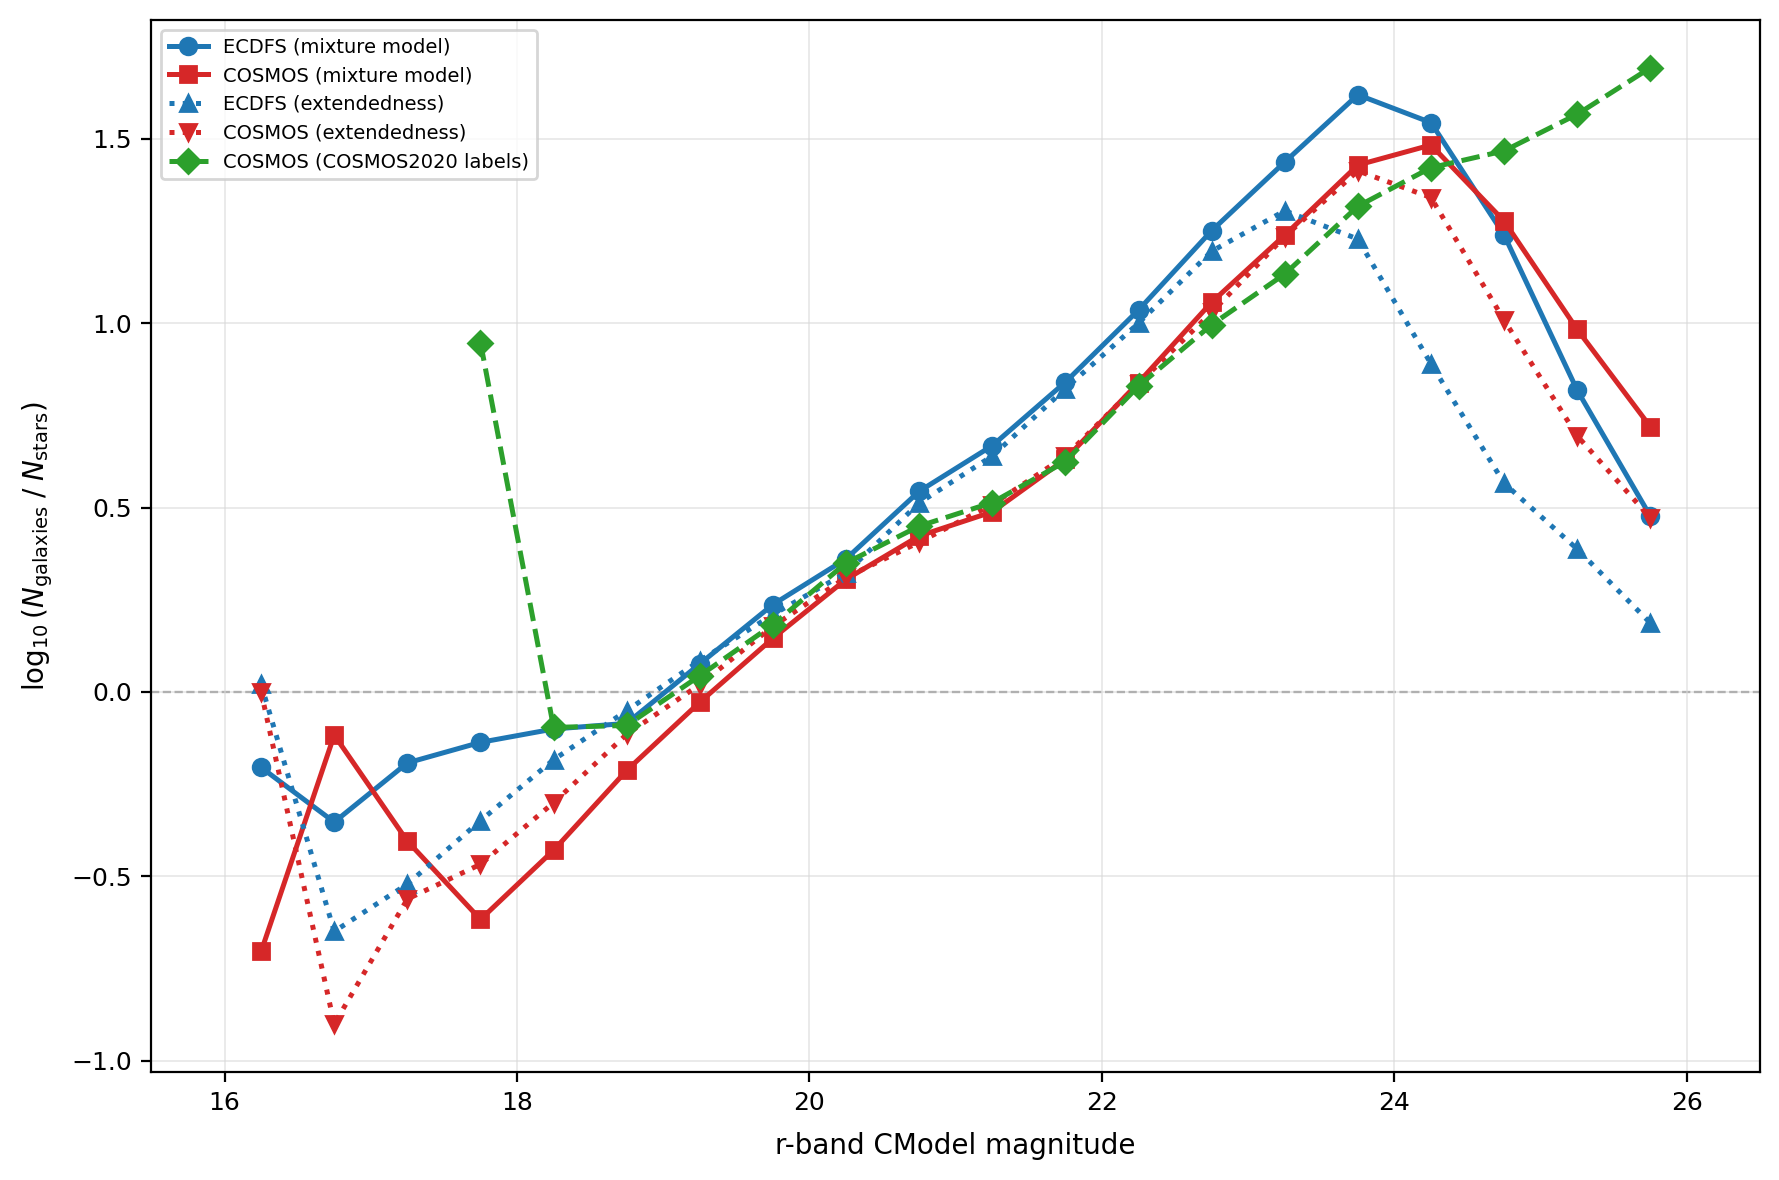

Saved: paper_convergence\figures\star_galaxy_ratio_vs_rmag.png
Saved: paper_convergence\figures\star_galaxy_ratio_vs_rmag.pdf


In [45]:
fig, ax = plt.subplots(figsize=(9, 6))

# Mixture model curves (solid)
mm_cfg = {
    'ECDFS': {'marker': 'o', 'color': '#1f77b4'},
    'COSMOS': {'marker': 's', 'color': '#d62728'},
}
for label in field_labels:
    valid = ratio_data[label][ratio_data[label]['valid']]
    cfg = mm_cfg[label]
    ax.plot(valid['mag_center'], valid['log_ratio'],
            marker=cfg['marker'], color=cfg['color'],
            ls='-', lw=1.8, ms=6, label=f'{label} (mixture model)')

# Extendedness curves (dotted)
ext_cfg = {
    'ECDFS': {'marker': '^', 'color': '#1f77b4'},
    'COSMOS': {'marker': 'v', 'color': '#d62728'},
}
for label in field_labels:
    valid = ext_ratio_data[label][ext_ratio_data[label]['valid']]
    cfg = ext_cfg[label]
    ax.plot(valid['mag_center'], valid['log_ratio'],
            marker=cfg['marker'], color=cfg['color'],
            ls=':', lw=1.8, ms=6, label=f'{label} (extendedness)')

# COSMOS2020 external labels (dashed)
valid_ext = cosmos_ext_ratio[cosmos_ext_ratio['valid']]
ax.plot(valid_ext['mag_center'], valid_ext['log_ratio'],
        marker='D', color='#2ca02c', ls='--', lw=1.8, ms=6,
        label='COSMOS (COSMOS2020 labels)')

ax.axhline(0, ls='--', lw=0.8, color='0.5', zorder=0)
ax.set_xlabel('r-band CModel magnitude')
ax.set_ylabel(r'$\log_{10}(N_{\rm galaxies}\;/\;N_{\rm stars})$')
ax.set_xlim(15.5, 26.5)
ax.legend(loc='best', fontsize=7)

plt.tight_layout()
plt.show()

saved = save_figure(fig, repo_root / 'paper_convergence' / 'figures' / 'star_galaxy_ratio_vs_rmag.png')
for p in saved:
    print(f'Saved: {p.relative_to(repo_root)}')

In [ ]:
from scipy.optimize import curve_fit
import importlib
pcf = importlib.reload(pcf)

# --- V9 3-step constrained fitting for both fields ---

LOG_WU_POLY_DEG = 1
WU_FIT_MAG_CUTOFF = 24.0

v9_ratio_data = {}

for field_idx, label in enumerate(field_labels):
    print(f'\n=== V9: {label} ===')

    # Step 1: free fit (same as V8 cell above — reuse fit_results if same bins)
    step1 = fit_results[label]

    # Step 2: smooth the star component
    centers = []
    muU_vals = []
    sigmaU_vals = []
    wU_vals = []
    for r in step1:
        if not r['success'] or r['params'] is None:
            continue
        p = r['params']
        n_res = r['n_resolved']
        wR = np.clip([p[2 + 4 * k] for k in range(n_res)], 0.0, 1.0)
        centers.append(r['cmodel_center'])
        muU_vals.append(p[0])
        sigmaU_vals.append(p[1])
        wU_vals.append(max(1.0 - np.sum(wR), 0.0))

    centers = np.array(centers)
    muU_vals = np.array(muU_vals)
    sigmaU_vals = np.array(sigmaU_vals)
    wU_vals = np.array(wU_vals)

    muU_fixed = float(np.median(muU_vals))

    # Sesar eq. 5 for sigmaU
    sU_p0 = (max(float(np.min(sigmaU_vals)), 1e-3),
             max(float(np.max(sigmaU_vals)), 1e-2), 0.4)
    try:
        sesar_popt, _ = curve_fit(
            pcf.sesar_sigma, centers, sigmaU_vals, p0=sU_p0,
            bounds=([1e-4, 1e-4, 0.0], [1.0, 5.0, 2.0]), maxfev=10000)
        sesar_ok = True
    except Exception as e:
        print(f'  Sesar fit failed: {e}')
        sesar_popt = None
        sesar_ok = False

    # Linear fit to log10(wU) using only bins < cutoff
    valid_wU = (wU_vals > 0) & (centers < WU_FIT_MAG_CUTOFF)
    if valid_wU.sum() >= LOG_WU_POLY_DEG + 1:
        wU_poly = np.polyfit(centers[valid_wU], np.log10(wU_vals[valid_wU]),
                             deg=LOG_WU_POLY_DEG)
    else:
        valid_all = wU_vals > 0
        wU_poly = np.polyfit(centers[valid_all], np.log10(wU_vals[valid_all]),
                             deg=LOG_WU_POLY_DEG)

    print(f'  muU_fixed = {muU_fixed:+.5f}, Sesar = {sesar_ok}, '
          f'wU poly deg = {LOG_WU_POLY_DEG} (cutoff = {WU_FIT_MAG_CUTOFF})')

    # Step 3: constrained refit
    all_bins = bright_bins + faint_bins
    bin_centers = np.array([0.5 * (lo + hi) for lo, hi in all_bins])

    if sesar_ok:
        sigmaU_arr = pcf.sesar_sigma(bin_centers, *sesar_popt)
    else:
        sigmaU_arr = np.interp(bin_centers, centers, sigmaU_vals)

    log_wU_smooth = np.polyval(wU_poly, bin_centers)
    wU_arr = np.clip(10.0 ** log_wU_smooth, 0.0, 1.0)

    fits_v9 = pcf.fit_slices_fixed_star(
        data_mag[field_idx], band, n_resolved=3,
        fixed_muU=muU_fixed, fixed_sigmaU=sigmaU_arr, fixed_wU=wU_arr,
        cmodel_bins=all_bins)
    fits_v9 = fallback_failed_bins(fits_v9)

    n_ok = sum(1 for r in fits_v9 if r['success'] and not r.get('fallback', False))
    n_fb = sum(1 for r in fits_v9 if r.get('fallback', False))
    print(f'  {n_ok} successful fits, {n_fb} fallbacks')

    # Extract counts
    rows = []
    for r in fits_v9:
        wU = extract_star_fraction(r)
        N = r['n']
        center = r['cmodel_center']
        if np.isnan(wU) or N == 0:
            rows.append({'mag_center': center, 'log_ratio': np.nan, 'valid': False})
            continue
        N_stars = wU * N
        N_galaxies = (1.0 - wU) * N
        if N_stars <= 0 or N_galaxies <= 0:
            rows.append({'mag_center': center, 'log_ratio': np.nan, 'valid': False})
        else:
            rows.append({'mag_center': center, 'log_ratio': np.log10(N_galaxies / N_stars),
                         'valid': True})

    v9_ratio_data[label] = pd.DataFrame(rows)

# --- Plot: V8 vs V9 comparison ---

fig, ax = plt.subplots(figsize=(9, 6))

# V8 mixture model (solid, thinner)
for label in field_labels:
    valid = ratio_data[label][ratio_data[label]['valid']]
    color = '#1f77b4' if label == 'ECDFS' else '#d62728'
    ax.plot(valid['mag_center'], valid['log_ratio'],
            marker='o' if label == 'ECDFS' else 's',
            color=color, ls='-', lw=1.2, ms=5, alpha=0.4,
            label=f'{label} (V8 mixture model)')

# V9 mixture model (solid, bold)
for label in field_labels:
    valid = v9_ratio_data[label][v9_ratio_data[label]['valid']]
    color = '#1f77b4' if label == 'ECDFS' else '#d62728'
    ax.plot(valid['mag_center'], valid['log_ratio'],
            marker='o' if label == 'ECDFS' else 's',
            color=color, ls='-', lw=2.2, ms=7,
            label=f'{label} (V9 constrained)')

# Extendedness (dotted)
for label in field_labels:
    valid = ext_ratio_data[label][ext_ratio_data[label]['valid']]
    color = '#1f77b4' if label == 'ECDFS' else '#d62728'
    ax.plot(valid['mag_center'], valid['log_ratio'],
            marker='^' if label == 'ECDFS' else 'v',
            color=color, ls=':', lw=1.5, ms=5,
            label=f'{label} (extendedness)')

# COSMOS2020 external labels (dashed green)
valid_ext = cosmos_ext_ratio[cosmos_ext_ratio['valid']]
ax.plot(valid_ext['mag_center'], valid_ext['log_ratio'],
        marker='D', color='#2ca02c', ls='--', lw=1.8, ms=6,
        label='COSMOS (COSMOS2020 labels)')

ax.axhline(0, ls='--', lw=0.8, color='0.5', zorder=0)
ax.set_xlabel('r-band CModel magnitude')
ax.set_ylabel(r'$\log_{10}(N_{\rm galaxies}\;/\;N_{\rm stars})$')
ax.set_xlim(15.5, 26.5)
ax.legend(loc='best', fontsize=6.5)

plt.tight_layout()
plt.show()

saved = save_figure(fig, repo_root / 'paper_convergence' / 'figures' / 'star_galaxy_ratio_vs_rmag_v8v9.png')
for p in saved:
    print(f'Saved: {p.relative_to(repo_root)}')